In this notebook I am building and testing a Leaky Integrate and Fire (LIF) model to see how a basic simulated neuron responds to different types of electrical inputs. LIF model simplifies the cell membrane into a basic RC circuit which is great for watching how a neuron takes in raw current and translates it into spikes.

I will be evaluating it's behaviour across three main areas:


1.   Subthreshold and Suprathreshold currents
2.   f-I curve
3. ISI and noise analysis

Ultimately this will lead to test the finding of Mainen and Sejnowski to see if adding noise to a input actually makes a neuron's spike timing more reliable.




In [1]:
import numpy as np
import matplotlib.pyplot as plt

# **Parameters**

In [2]:
tau_m = 10 # time constant (ms)
R = 10 # Resistance
E_L = -65 # Leak potential (mV)
V_th = -50 # Threshold (mV)
V_reset = -65 # Reset potential (mV)
dt = 0.1 # Time step (ms)
T = 500 # simulation time
time = np.arange(0, T, dt) # clock everything else runs on

# **LIF Function**

In [3]:
time = np.arange(0, T, dt)
n_steps = len(time)

def LIF(I_ext):
    """
    I_ext can be a single float value(constant current)
    or a numpy array(noisy current).
    """
    V = np.zeros(n_steps)
    V[0] = E_L
    spike_times = []

    if isinstance(I_ext, (int, float)):
        I_input = np.full(n_steps, I_ext)
    else:
        I_input = I_ext

    for t in range(1, n_steps):
        if V[t-1] >= V_th:
            V[t] = V_reset
        else:
            V[t] = V[t-1] + ((-V[t-1] + E_L + R * I_input[t]) / tau_m) * dt
            if V[t] >= V_th:
                spike_times.append(time[t])
                V[t] = 0

    isi = np.diff(spike_times)
    return V, spike_times, isi

# **Subthreshold behaviour**

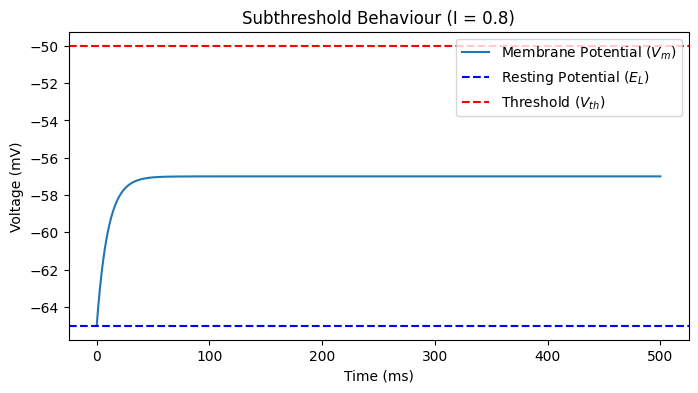

In [4]:
V_sub, _, _ = LIF(0.8)

plt.figure(figsize=(8, 4))
plt.plot(time, V_sub, label="Membrane Potential ($V_m$)")
plt.axhline(E_L, color="blue", linestyle='--', label="Resting Potential ($E_{L}$)")
plt.axhline(V_th, color="red", linestyle='--', label="Threshold ($V_{th}$)")
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.title("Subthreshold Behaviour (I = 0.8)")
plt.legend(loc='best')
plt.show()

# **Suprathreshold spiking**

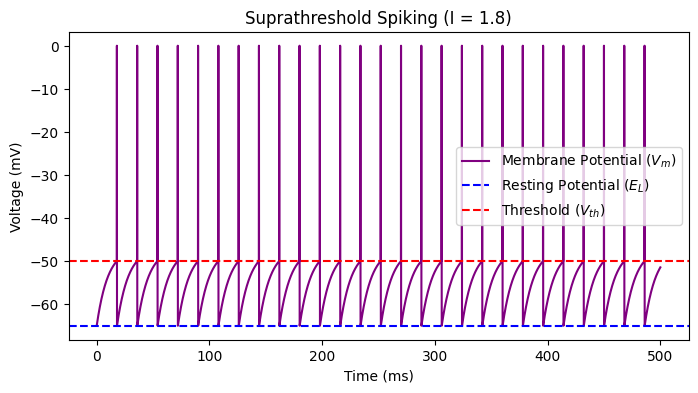

In [5]:
V_sup, _, _ = LIF(1.8)

plt.figure(figsize=(8, 4))
plt.plot(time, V_sup, color="purple", label="Membrane Potential ($V_m$)")
plt.axhline(E_L, color="blue", linestyle='--', label="Resting Potential ($E_{L}$)")
plt.axhline(V_th, color="red", linestyle='--', label="Threshold ($V_{th}$)")
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.title("Suprathreshold Spiking (I = 1.8)")
plt.legend(loc='best')
plt.show()

# **f-I curve**

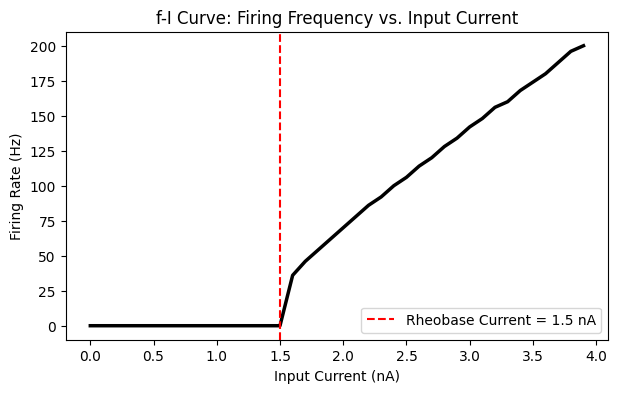

In [6]:
current_range = np.arange(0, 4.0, 0.1)
firing_rates = []

for idx in range(len(current_range)):
    _, spike_times, _ = LIF(current_range[idx])
    # Converting total spike count over 500 ms to Hz
    rate = len(spike_times) / (T / 1000.0)
    firing_rates.append(rate)

plt.figure(figsize=(7, 4))
plt.plot(current_range, firing_rates, color="black", linewidth=2.5)
plt.xlabel("Input Current (nA)")
plt.ylabel("Firing Rate (Hz)")
plt.title("f-I Curve: Firing Frequency vs. Input Current")
plt.axvline(1.5, color="red", linestyle="--", label="Rheobase Current = 1.5 nA")
plt.legend()
plt.show()

The curve is flat because the input current is not enough to overcome the leaky current, it is not linear because it is the type 1 neuron which gets triggered at certain current level and below that level it remains at 0Hz


# **ISI analysis**

Constant Current CV: 3.215330161216962e-16
Noisy Current CV: 0.04062711833165072


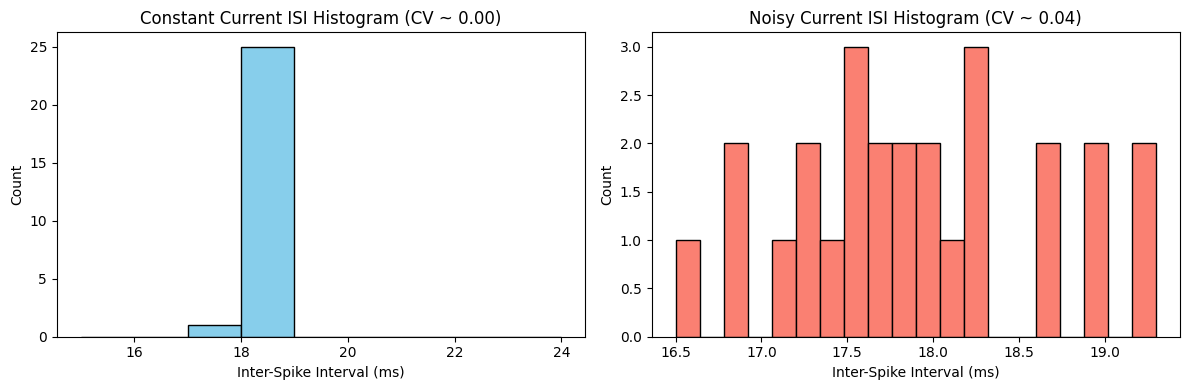

In [7]:
# 1. Constant Input Analysis
_, _, isi_const = LIF(1.8)
cv_const = np.std(isi_const) / np.mean(isi_const)
print(f"Constant Current CV: {cv_const}")

# 2. Noisy Input Analysis
I_const_arr = np.full(n_steps, 1.8)
I_noisy_arr = I_const_arr + np.random.normal(0, 0.3, n_steps)
_, _, isi_noisy = LIF(I_noisy_arr)
cv_noisy = np.std(isi_noisy) / np.mean(isi_noisy)
print(f"Noisy Current CV: {cv_noisy}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(isi_const, bins=np.arange(15, 25, 1), color='skyblue', edgecolor='black')
ax1.set_xlabel("Inter-Spike Interval (ms)")
ax1.set_ylabel("Count")
ax1.set_title(f"Constant Current ISI Histogram (CV ~ {cv_const:.2f})")

ax2.hist(isi_noisy, bins=20, color='salmon', edgecolor='black')
ax2.set_xlabel("Inter-Spike Interval (ms)")
ax2.set_ylabel("Count")
ax2.set_title(f"Noisy Current ISI Histogram (CV ~ {cv_noisy:.2f})")

plt.tight_layout()
plt.show()

If the experiment is repeated across multiple trials, the absolute timestamps of the spikes vary greatly. If these trials are plotted on top of each other, they do not line up. It cannot convey a message because an unvarying stream has zero information capacity while fluctuating noisy current produces a wide, scattered histogram within a single run and if the exact same noisy wave pattern is repeated across multiple trials, the neuron will fire at the exact same microscopic timestamps every single time.


By forcing the neuron to lock its spikes directly to the sharp changes in the noise, the brain is able to send precise reproducible messages.
